<a href="https://colab.research.google.com/github/SlastuninAE/python-practice-algos/blob/master/hw_4_slastunin_a_e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
california_data = fetch_california_housing(as_frame=True)
df = california_data.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## 3. Data Understanding

### 3.1 First Look

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


### 3.2 Shape & Info

In [4]:
print('Shape:', df.shape)
df.info()

Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### 3.3 Statistical Summary

In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### 3.4 Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

### 3.5 Missing Values

In [8]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


### 3.6 Unique Values

In [9]:
df.nunique()

,0
MedInc,12928
HouseAge,52
AveRooms,19392
AveBedrms,14233
Population,3888
AveOccup,18841
Latitude,862
Longitude,844
MedHouseVal,3842


## 4. EDA

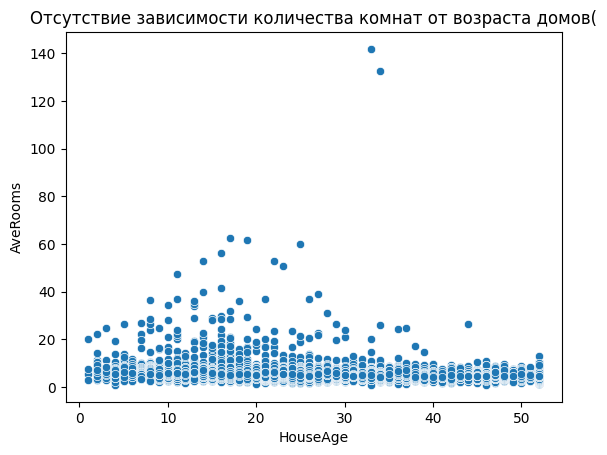

In [10]:
sns.scatterplot(df, x='HouseAge', y='AveRooms')
plt.title("Отсутствие зависимости количества комнат от возраста домов(")
plt.show()

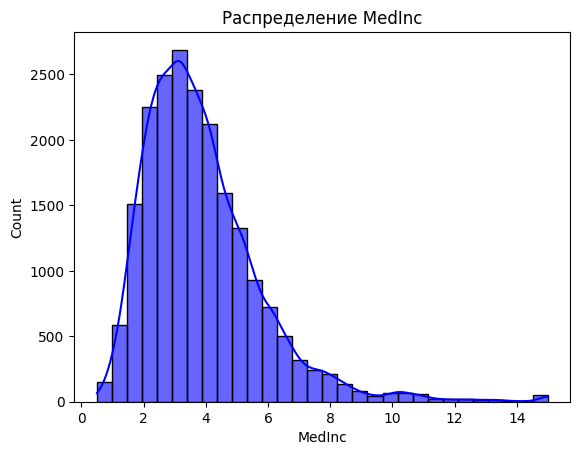

In [11]:
sns.histplot(df['MedInc'], bins=30, kde=True, color='blue', alpha=0.6)
plt.xlabel('MedInc')
plt.title('Распределение MedInc')
plt.show()

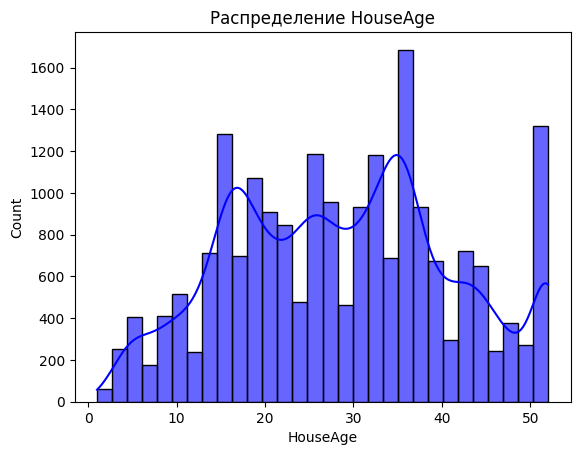

In [12]:
sns.histplot(df['HouseAge'], bins=30, kde=True, color='blue', alpha=0.6)
plt.xlabel('HouseAge')
plt.title('Распределение HouseAge')
plt.show()

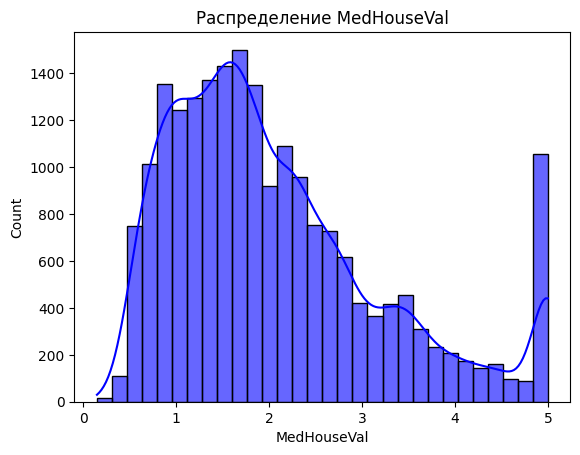

In [13]:
sns.histplot(df['MedHouseVal'], bins=30, kde=True, color='blue', alpha=0.6)
plt.xlabel('MedHouseVal')
plt.title('Распределение MedHouseVal')
plt.show()

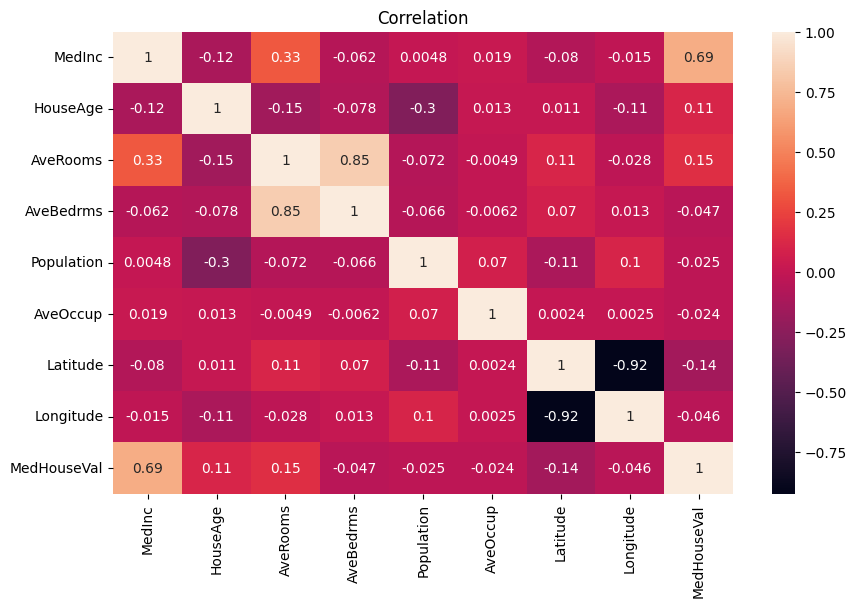

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot = True)
plt.title("Correlation")
plt.show()

## 5. Outliers

In [15]:
cols = ['MedInc',
        'HouseAge',
        'AveRooms',
        'AveBedrms',
        'Population',
        'AveOccup',
        'Latitude',
        'Longitude',
        'MedHouseVal']

# IQR method
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(col, '->', n, 'outliers')

MedInc -> 681 outliers
HouseAge -> 0 outliers
AveRooms -> 511 outliers
AveBedrms -> 1424 outliers
Population -> 1196 outliers
AveOccup -> 711 outliers
Latitude -> 0 outliers
Longitude -> 0 outliers
MedHouseVal -> 1071 outliers


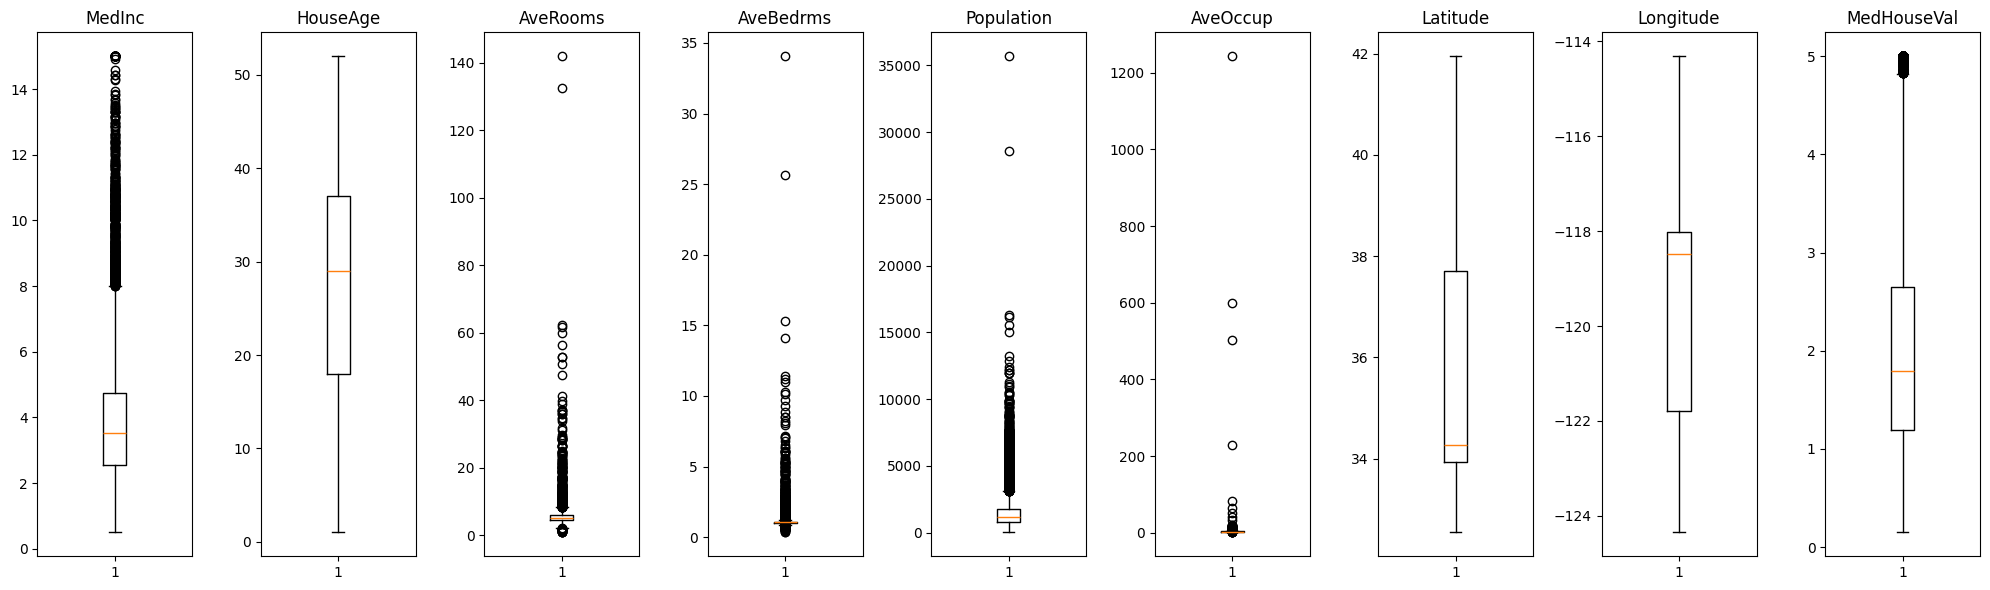

In [16]:
fig, axes = plt.subplots(1, 9, figsize=(20, 6))
for ax, col in zip(axes, cols):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 6. Encoding

In [17]:
x = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print('Shape:', x.shape)
x.head()

Shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 7. Train / Test Split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=47)

In [24]:
x_train.shape

(16512, 8)

In [25]:
x_test.shape

(4128, 8)

## 8. Feature Scaling

In [26]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 9. Model Training

In [44]:
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge()
}

default_acc = {}

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_pred)

    default_acc[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
    }
    print(f"{name} -> MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

LinearRegression -> MSE: 0.5218, RMSE: 0.7223, MAE: 0.5328
ElasticNet -> MSE: 1.0814, RMSE: 1.0399, MAE: 0.8219
Lasso -> MSE: 1.3629, RMSE: 1.1674, MAE: 0.9264
Ridge -> MSE: 0.5218, RMSE: 0.7223, MAE: 0.5328
